# **Clustering Handwritten Digits Using K-Means**

## **Introduction:**

In this project, we will explore unsupervised learning. We will use the MNIST handwritten digit dataset, which contains images of handwritten numbers from 0 to 9 to explore if K-Means clustering can discover meaningful groups of similar handwritten digits without being told which digit each image represents.

## **Load the dataset**

In [13]:
# Import libraries

from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# Load MNIST dataset

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False)

X = mnist.data
y = mnist.target

## **Part 1 — Explore the Images**

### **1.1 Check the size of the data**

In [4]:
print("Shape:", X.shape)
print("Number of images:", X.shape[0])
print("Number of features:", X.shape[1])
print("Data type:", X.dtype)
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Shape: (70000, 784)
Number of images: 70000
Number of features: 784
Data type: int64
Minimum pixel value: 0
Maximum pixel value: 255


### **Insights**

The dataset contains 70,000 handwritten digit images. Each image is 28 × 28 pixels. When flattened into a single row, this gives 28 × 28 = 784 features. The pixel values represent the intensity of each pixel in the image. They range from 0 to 255.

### **1.2 Understand the 784 features and Display sample images**

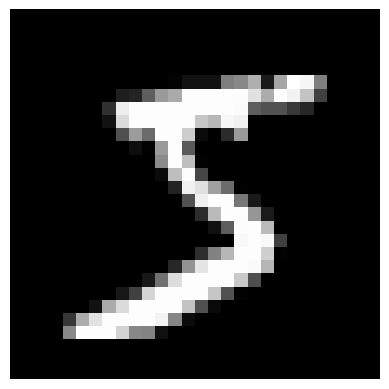

In [ ]:
# Displaye one image 

plt.imshow(
X[0].reshape(28, 28),
cmap="gray"
)
plt.axis("off")
plt.show()

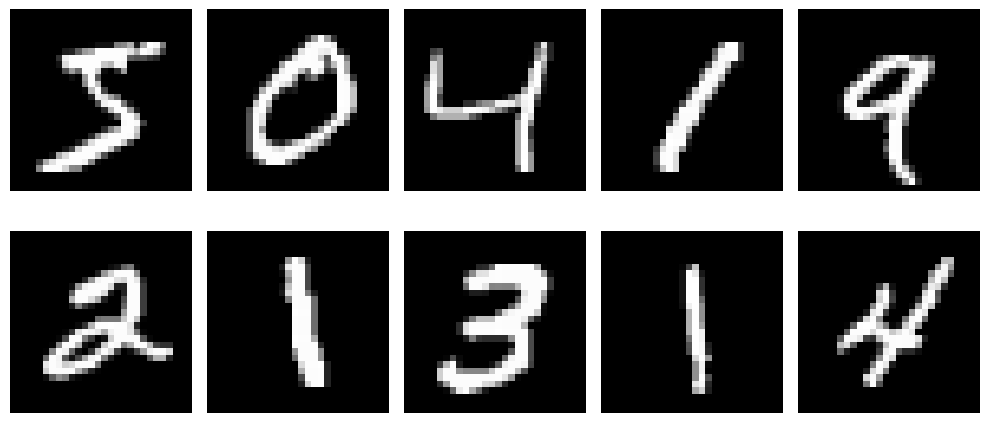

In [ ]:
# Display images

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

### **1.3 Normalize the pixel values**

In [ ]:
# Normalize the pixels

X = X / 255.0

In [11]:
# Verify the normalization

print("Minimum after normalization:", X.min())
print("Maximum after normalization:", X.max())

Minimum after normalization: 0.0
Maximum after normalization: 1.0


#### **Insights:**

The normalization tranformed the values from 0–255 to 0–1. This helps to have the pixel features on a smaller, consistent scale makeing them to be compared for K-Means algorithm.

## **Part 2 — Discover Groups Using K-Means**

### **Create a Sample of 10,000 Images**

In [12]:
# Create a Sample of 10,000 Images

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X),
    size=10000,
    replace=False)

X_sample = X[sample_indices]
y_sample = y[sample_indices]

print("X sample shape:", X_sample.shape)
print("y sample shape:", y_sample.shape)

X sample shape: (10000, 784)
y sample shape: (10000,)


### **Find a reasonable number of clusters**

In [ ]:
# Compare K = 5, 10, and 15

k_values = [5, 10, 15]
inertia = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_sample)
    inertia.append(kmeans.inertia_)

print(inertia)

[432527.7509384544, 390343.06280820153, 365525.2325064656]


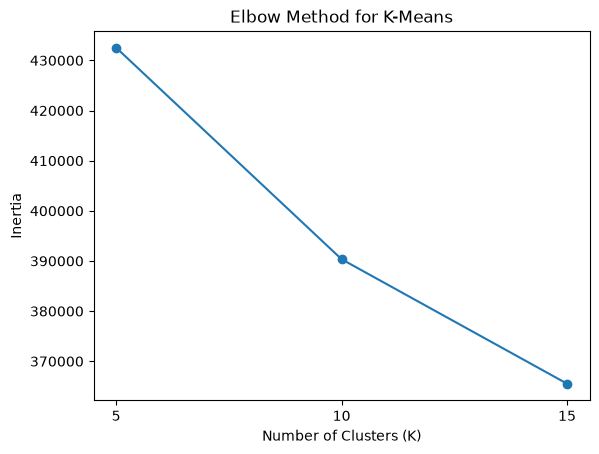

In [15]:
# Create the Elbow Plot

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.show()

#### **Insights**:

Inertia decreases as the number of clusters increases. The largest decrease occurs between K = 5 and K = 10. From K = 10 to K = 15, inertia continues to decrease, but at a slower rate. This creates an elbow around K = 10. This suggests that adding clusters beyond 10 provides less improvement.

### **Train final K-Means model**

In [17]:
# Train final K-Means model

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10)

clusters = kmeans.fit_predict(X_sample)

In [18]:
# Check the cluster size

cluster_sizes = pd.Series(clusters).value_counts().sort_index()

print(cluster_sizes)

0     519
1     757
2    1487
3    1039
4    1475
5    1331
6     513
7     906
8    1017
9     956
Name: count, dtype: int64


In [19]:
cluster_table = cluster_sizes.reset_index()
cluster_table.columns = ["Cluster", "Number of Images"]

cluster_table

,Cluster,Number of Images
0,0,519
1,1,757
2,2,1487
3,3,1039
4,4,1475
5,5,1331
6,6,513
7,7,906
8,8,1017
9,9,956


In [ ]:
# Total images 

print("Total images:", cluster_sizes.sum())

Total images: 10000


### **Insigts**:

The cluster sizes vary considerably, from 513 images in Cluster 6 to 1,487 images in Cluster 2. This suggests that K-Means did not divide the images into equally sized groups, which is expected because it groups images according to similarities in their pixel patterns rather than trying to create equal-sized clusters.